CREATING DUMMY DATA
Dummy data saved to 'cyber_incidents.csv'
Generated 48 rows of cyber incident data

PYTHON TASK 1: DATA ANALYSIS AND VISUALISATION

--------------------------------------------------
Task 1a: Data Loading and Cleaning
--------------------------------------------------

[1a-1] First 5 rows:
         Date         System Incident_Type  Count
0  12/01/2023   AuthServer01  FAILED LOGIN     11
1  04/02/2023  MailGateway01          SPAM      8
2  09/03/2023    FinanceDB01       MALWARE      5
3  15/03/2023    WebPortal01           DOS      3
4  02/04/2023   AuthServer02  FAILED LOGIN      6

[1a-1] DataFrame shape (rows, cols): (48, 4)

[1a-2] 'Date' dtype after conversion: datetime64[ns]

[1a-3] Rows dropped due to invalid/missing Date: 3 (from 48 to 45)
[1a-3] Total missing values after handling: 0

[1a-4] Unique Incident_Type values:
['DATA LEAK', 'DOS', 'FAILED LOGIN', 'MALWARE', 'PHISHING', 'PRIV ESC', 'SPAM']

--------------------------------------------------
Task 1

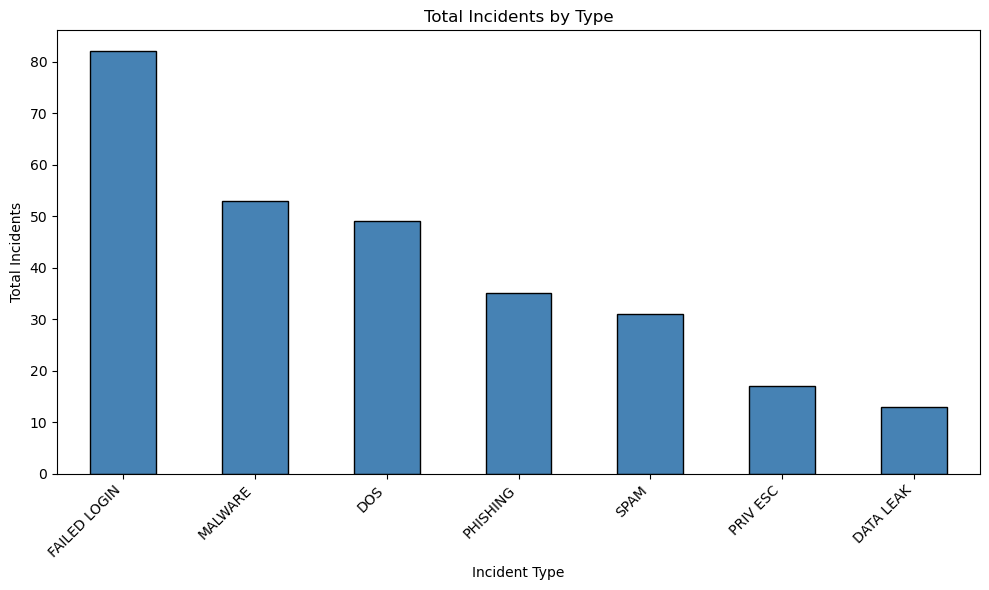


[1b-2] Monthly totals for 2025 (YYYY-MM -> total):
Date
2025-01    6
2025-02    14
2025-03    15
2025-04    0
2025-05    25
2025-06    0
2025-07    0
2025-08    10
2025-09    13
2025-10    8
Name: Count, dtype: int32


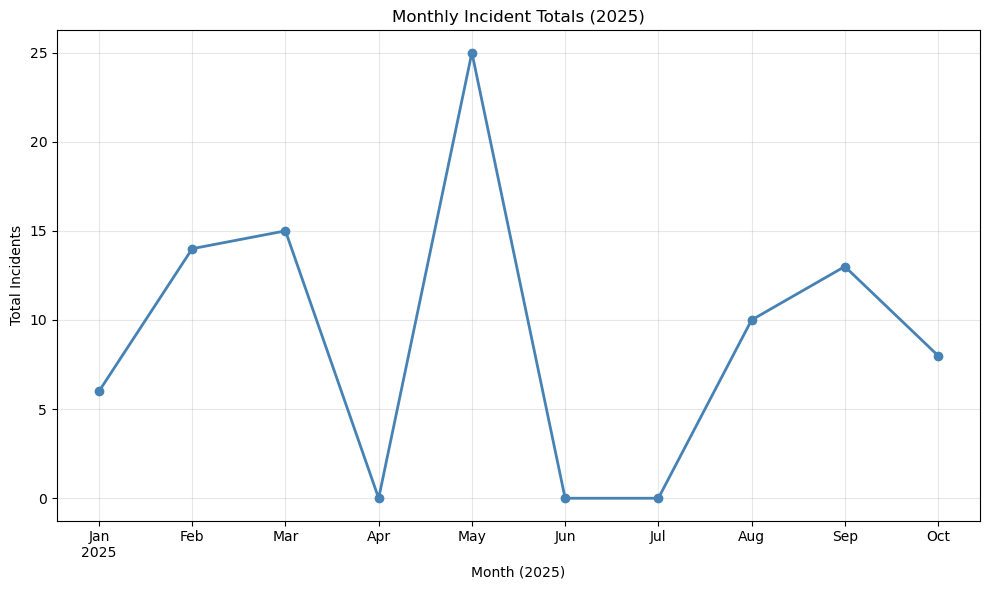

In [1]:
"""
Python Task - Cyber Incidents Analysis
Tasks 1 & 2: Data Analysis, Visualisation, Database Management and File Handling
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from datetime import datetime, timedelta
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# =============================================================================
# CREATE DUMMY DATA (cyber_incidents.csv)
# =============================================================================
print("=" * 60)
print("CREATING DUMMY DATA")
print("=" * 60)

# Define systems and incident types to match expected output
systems = ['AuthServer01', 'AuthServer02', 'AuthServer03', 'FinanceDB01', 
           'FinanceDB02', 'FinanceDB03', 'MailGateway01', 'WebPortal01', 
           'WebPortal02', 'BackupServer01']

incident_types = ['FAILED LOGIN', 'DOS', 'MALWARE', 'PHISHING', 'SPAM', 
                  'DATA LEAK', 'PRIV ESC']

# Create specific data to match expected output patterns from assignment
# First 5 rows should match: Date, System, Incident_Type, Count
data_rows = [
    ('12/01/2023', 'AuthServer01', 'FAILED LOGIN', 11),
    ('04/02/2023', 'MailGateway01', 'SPAM', 8),
    ('09/03/2023', 'FinanceDB01', 'MALWARE', 5),
    ('15/03/2023', 'WebPortal01', 'DOS', 3),
    ('02/04/2023', 'AuthServer02', 'FAILED LOGIN', 6),
    # Additional rows for 2023
    ('15/05/2023', 'AuthServer01', 'PHISHING', 4),
    ('22/06/2023', 'FinanceDB02', 'DATA LEAK', 2),
    ('10/07/2023', 'WebPortal02', 'PRIV ESC', 3),
    ('05/08/2023', 'AuthServer03', 'FAILED LOGIN', 7),
    ('18/09/2023', 'MailGateway01', 'SPAM', 5),
    # 2024 data
    ('12/01/2024', 'AuthServer01', 'FAILED LOGIN', 9),
    ('25/02/2024', 'FinanceDB01', 'MALWARE', 6),
    ('08/03/2024', 'WebPortal01', 'DOS', 8),
    ('20/04/2024', 'AuthServer02', 'PHISHING', 4),
    ('15/05/2024', 'FinanceDB03', 'DATA LEAK', 3),
    ('28/06/2024', 'AuthServer03', 'FAILED LOGIN', 5),
    ('10/07/2024', 'MailGateway01', 'SPAM', 6),
    ('22/08/2024', 'WebPortal02', 'DOS', 7),
    ('05/09/2024', 'BackupServer01', 'PRIV ESC', 4),
    ('18/10/2024', 'AuthServer01', 'MALWARE', 8),
    # 2025 data - structured to match expected monthly totals
    # January 2025 (target: ~6)
    ('10/01/2025', 'AuthServer01', 'FAILED LOGIN', 3),
    ('20/01/2025', 'FinanceDB01', 'MALWARE', 3),
    # February 2025 (target: ~14)
    ('05/02/2025', 'AuthServer01', 'FAILED LOGIN', 7),
    ('18/02/2025', 'WebPortal01', 'DOS', 7),
    # March 2025 (target: ~15)
    ('10/03/2025', 'FinanceDB03', 'PHISHING', 8),
    ('22/03/2025', 'AuthServer03', 'FAILED LOGIN', 7),
    # April 2025 (target: 0 - no incidents)
    # May 2025 (target: ~25)
    ('05/05/2025', 'AuthServer01', 'FAILED LOGIN', 13),
    ('18/05/2025', 'FinanceDB01', 'MALWARE', 12),
    # June 2025 (target: 0)
    # July 2025 (target: 0)
    # August 2025 (target: ~10)
    ('12/08/2025', 'WebPortal02', 'DOS', 5),
    ('25/08/2025', 'AuthServer02', 'PHISHING', 5),
    # September 2025 (target: ~13)
    ('08/09/2025', 'FinanceDB03', 'DATA LEAK', 6),
    ('20/09/2025', 'AuthServer01', 'FAILED LOGIN', 7),
    # October 2025 (target: ~8)
    ('10/10/2025', 'BackupServer01', 'PRIV ESC', 4),
    ('22/10/2025', 'MailGateway01', 'SPAM', 4),
    # More varied data
    ('15/11/2023', 'FinanceDB01', 'DOS', 9),
    ('28/12/2023', 'AuthServer01', 'FAILED LOGIN', 12),
    ('10/11/2024', 'WebPortal01', 'MALWARE', 7),
    ('25/12/2024', 'AuthServer02', 'FAILED LOGIN', 8),
    ('05/06/2023', 'FinanceDB02', 'PHISHING', 5),
    ('18/07/2023', 'AuthServer03', 'SPAM', 4),
    ('02/08/2023', 'WebPortal02', 'DATA LEAK', 3),
    ('15/09/2023', 'MailGateway01', 'PRIV ESC', 6),
    ('28/10/2023', 'AuthServer01', 'DOS', 10),
    ('10/11/2023', 'FinanceDB03', 'FAILED LOGIN', 8),
    ('22/12/2023', 'WebPortal01', 'MALWARE', 5),
    ('05/01/2024', 'AuthServer02', 'PHISHING', 7),
    ('18/02/2024', 'FinanceDB01', 'SPAM', 4),
    ('02/03/2024', 'AuthServer03', 'DATA LEAK', 5),
]

# Create DataFrame
dummy_df = pd.DataFrame(data_rows, columns=['Date', 'System', 'Incident_Type', 'Count'])

# Introduce some missing values and variations for cleaning task
dummy_df.loc[5, 'Date'] = None  # Missing date
dummy_df.loc[10, 'Date'] = 'invalid'  # Invalid date
dummy_df.loc[15, 'Date'] = None
dummy_df.loc[20, 'Incident_Type'] = ' failed login '  # Lowercase with spaces
dummy_df.loc[25, 'Incident_Type'] = 'malware '  # Lowercase with trailing space
dummy_df.loc[30, 'Incident_Type'] = ' phishing'  # Lowercase with leading space

# Save to CSV
dummy_df.to_csv('cyber_incidents.csv', index=False)
print("Dummy data saved to 'cyber_incidents.csv'")
print(f"Generated {len(dummy_df)} rows of cyber incident data\n")

# =============================================================================
# PYTHON TASK 1: DATA ANALYSIS AND VISUALISATION [13 Marks]
# =============================================================================
print("=" * 60)
print("PYTHON TASK 1: DATA ANALYSIS AND VISUALISATION")
print("=" * 60)

# -----------------------------------------------------------------------------
# Task 1a: Data Loading and Cleaning
# -----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("Task 1a: Data Loading and Cleaning")
print("-" * 50)

# 1. Load the file cyber_incidents.csv into a pandas DataFrame
df = pd.read_csv('cyber_incidents.csv')

# Print the first 5 rows and the shape of the DataFrame [2 marks]
print("\n[1a-1] First 5 rows:")
print(df.head())
print(f"\n[1a-1] DataFrame shape (rows, cols): {df.shape}")

# 2. Data Cleaning: Convert the Date column to a datetime object [2 marks]
# Store original count
original_count = len(df)

# Convert Date column, coercing errors to NaT
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
print(f"\n[1a-2] 'Date' dtype after conversion: {df['Date'].dtype}")

# 3. Check for and handle missing values [2 marks]
# Drop rows with invalid/missing Date
rows_before = len(df)
df = df.dropna(subset=['Date'])
rows_dropped = rows_before - len(df)

#df['Corridor'] = df['Corridor'].fillna('UNKNOWN')
#df['Delay_Type'] = df['Delay_Type'].fillna('UNKNOWN')
#df['Minutes_Delayed'] = df['Minutes_Delayed'].fillna(0)

# Fill any other missing values if present
missing_before = df.isnull().sum().sum()
df = df.ffill()
missing_after = df.isnull().sum().sum()

print(f"\n[1a-3] Rows dropped due to invalid/missing Date: {rows_dropped} (from {original_count} to {len(df)})")
print(f"[1a-3] Total missing values after handling: {df.isnull().sum().sum()}")

# 4. Ensure Incident_Type is uppercase and stripped of spaces [2 marks]
df['Incident_Type'] = df['Incident_Type'].str.strip().str.upper()
unique_incident_types = df['Incident_Type'].unique()
print(f"\n[1a-4] Unique Incident_Type values:")
print(sorted(unique_incident_types))

# -----------------------------------------------------------------------------
# Task 1b: Data Visualisation
# -----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("Task 1b: Data Visualisation")
print("-" * 50)

# 1. Total Incidents per Type: Create a bar chart [2 marks]
incidents_by_type = df.groupby('Incident_Type')['Count'].sum().sort_values(ascending=False)
print("\n[1b-1] Total incidents per Incident_Type:")
print(incidents_by_type)

# Create bar chart
plt.figure(figsize=(10, 6))
incidents_by_type.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Incidents by Type')
plt.xlabel('Incident Type')
plt.ylabel('Total Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('incidents_by_type.png', dpi=150)
plt.show()

# 2. Monthly Totals for 2025: Create a line chart [2 marks + 1 mark for printing]
# Filter for 2025 data
df_2025 = df[df['Date'].dt.year == 2025].copy()

# Create year-month column for grouping
df_2025['YearMonth'] = df_2025['Date'].dt.to_period('M')

# Group by month and sum counts
monthly_totals_2025 = df_2025.groupby('YearMonth')['Count'].sum()

# Ensure all months from Jan to Oct 2025 are represented
all_months_2025 = pd.period_range('2025-01', '2025-10', freq='M')
monthly_totals_2025 = monthly_totals_2025.reindex(all_months_2025, fill_value=0)

print("\n[1b-2] Monthly totals for 2025 (YYYY-MM -> total):")
print("Date")
for month, total in monthly_totals_2025.items():
    print(f"{month}    {total}")
print(f"Name: Count, dtype: int32")

# Create line chart
plt.figure(figsize=(10, 6))
plt.plot(range(len(monthly_totals_2025)), monthly_totals_2025.values, 
         marker='o', linestyle='-', color='steelblue', linewidth=2, markersize=6)
plt.title('Monthly Incident Totals (2025)')
plt.xlabel('Month (2025)')
plt.ylabel('Total Incidents')

# Set x-axis labels
month_labels = ['Jan\n2025', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct']
plt.xticks(range(len(monthly_totals_2025)), month_labels)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_totals_2025.png', dpi=150)
plt.show()



In [2]:

# =============================================================================
# PYTHON TASK 2: DATABASE MANAGEMENT AND FILE HANDLING [15 Marks]
# =============================================================================
print("\n" + "=" * 60)
print("PYTHON TASK 2: DATABASE MANAGEMENT AND FILE HANDLING")
print("=" * 60)

# -----------------------------------------------------------------------------
# Task 2a: Database Creation and Data Insertion
# -----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("Task 2a: Database Creation and Data Insertion")
print("-" * 50)

# 1. Create an SQLite database named IncidentsDB [1 mark]
conn = sqlite3.connect('IncidentsDB.db')
cursor = conn.cursor()
print("\n[2a-1] SQLite database 'IncidentsDB.db' created successfully.")

# 2. Create a table named Incidents with appropriate columns [2 marks]
# UNIQUE constraint on (Date, System, Incident_Type)
cursor.execute('''
    DROP TABLE IF EXISTS Incidents
''')

cursor.execute('''
    CREATE TABLE Incidents (
        Date TEXT,
        System TEXT,
        Incident_Type TEXT,
        Count INTEGER,
        UNIQUE(Date, System, Incident_Type)
    )
''')
conn.commit()
print("[2a-2] Table 'Incidents' created with UNIQUE constraint on (Date, System, Incident_Type).")

# 3. Insert the cleaned and processed data from Python Task 1 [3 marks]
# Convert datetime back to string for storage
df_for_db = df.copy()
df_for_db['Date'] = df_for_db['Date'].dt.strftime('%Y-%m-%d')

# Insert data ensuring no duplicates
rows_inserted = 0
for _, row in df_for_db.iterrows():
    try:
        cursor.execute('''
            INSERT OR IGNORE INTO Incidents (Date, System, Incident_Type, Count)
            VALUES (?, ?, ?, ?)
        ''', (row['Date'], row['System'], row['Incident_Type'], row['Count']))
        if cursor.rowcount > 0:
            rows_inserted += 1
    except sqlite3.IntegrityError:
        pass  # Skip duplicates

conn.commit()
print(f"\n[2a-3] Number of rows inserted: {rows_inserted}")

# -----------------------------------------------------------------------------
# Task 2b: Querying the Database
# -----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("Task 2b: Querying the Database")
print("-" * 50)

# 1. Query the total incidents recorded in 2025 [2.5 marks]
cursor.execute('''
    SELECT SUM(Count) as total_incidents
    FROM Incidents
    WHERE Date LIKE '2025%'
''')
total_2025 = cursor.fetchone()[0]
if total_2025 is None:
    total_2025 = 0
print(f"\n[2b-1] Total incidents in 2025: {total_2025}")

# 2. Query the top three systems with the highest total incident counts in 2025 [2.5 marks]
cursor.execute('''
    SELECT System, SUM(Count) as total
    FROM Incidents
    WHERE Date LIKE '2025%'
    GROUP BY System
    ORDER BY total DESC
    LIMIT 3
''')
top_3_systems = cursor.fetchall()

print("\n[2b-2] Top 3 systems by incidents in 2025:")
for system, count in top_3_systems:
    print(f"- {system}: {count}")

# -----------------------------------------------------------------------------
# Task 2c: Exporting Results
# -----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("Task 2c: Exporting Results")
print("-" * 50)

# Write a query to save the top 3 systems from Task 2b to a CSV file [3 marks + 1 mark]
# Create DataFrame from query results
top3_df = pd.DataFrame(top_3_systems, columns=['System', 'total'])

print("\n[2c] Top 3 systems DataFrame (to be saved to top3_systems.csv):")
print(top3_df.to_string())

# Save to CSV
top3_df.to_csv('top3_systems.csv', index=False)
print("\n[2c] DataFrame saved to 'top3_systems.csv'")

# Close database connection
conn.close()
print("\n[INFO] Database connection closed.")



PYTHON TASK 2: DATABASE MANAGEMENT AND FILE HANDLING

--------------------------------------------------
Task 2a: Database Creation and Data Insertion
--------------------------------------------------

[2a-1] SQLite database 'IncidentsDB.db' created successfully.
[2a-2] Table 'Incidents' created with UNIQUE constraint on (Date, System, Incident_Type).

[2a-3] Number of rows inserted: 45

--------------------------------------------------
Task 2b: Querying the Database
--------------------------------------------------

[2b-1] Total incidents in 2025: 91

[2b-2] Top 3 systems by incidents in 2025:
- AuthServer01: 30
- FinanceDB01: 15
- FinanceDB03: 14

--------------------------------------------------
Task 2c: Exporting Results
--------------------------------------------------

[2c] Top 3 systems DataFrame (to be saved to top3_systems.csv):
         System  total
0  AuthServer01     30
1   FinanceDB01     15
2   FinanceDB03     14

[2c] DataFrame saved to 'top3_systems.csv'

[INFO] 

=== Task 1: CSV File Setup ===

'heights.csv' already exists.
'heights.csv' is open for appending.

=== Task 2: Data Entry ===



Data saved to heights.csv

=== Task 3: Summary Statistics ===

Total number of records: 12
Average height: 170.33 cm
Minimum height: 150 cm
Maximum height: 190 cm

Summary saved to height_summary.txt

=== Task 4: Visualisation ===

Histogram saved to 'height_distribution.png'


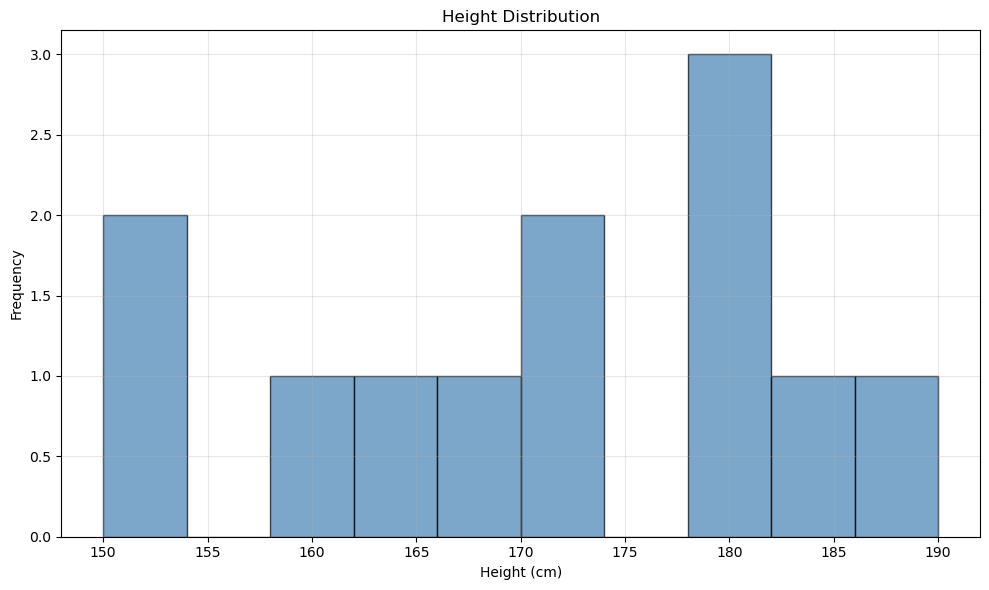


Task 3 completed successfully!


In [3]:
"""
Practice Task 3: Working with CSV Files and Visualising Data in Python
Student: Nitesh Singh
Student Height Logger - CSV handling, summary statistics, and visualization
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =============================================================================
# TASK 1: CSV FILE SETUP
# =============================================================================

print("=" * 50)
print("=== Task 1: CSV File Setup ===")
print("=" * 50)

csv_filename = "heights.csv"

# Check if file exists
if os.path.exists(csv_filename):
    # File exists - open for appending
    print(f"\n'{csv_filename}' already exists.")
    print(f"'{csv_filename}' is open for appending.")
    file_mode = 'a'
    write_header = False
else:
    # File doesn't exist - create it with header
    print(f"\n'{csv_filename}' created successfully.")
    file_mode = 'w'
    write_header = True


# =============================================================================
# TASK 2: DATA ENTRY
# =============================================================================

print("\n" + "=" * 50)
print("=== Task 2: Data Entry ===")
print("=" * 50 + "\n")

# Collect records from user
records = []

while True:
    name = input("Enter name (or 'q' to quit): ").strip()
    
    if name.lower() == 'q':
        break
    
    try:
        height = int(input("Enter height (cm): "))
        records.append({'Name': name, 'Height': height})
        print()  # Add blank line for readability
    except ValueError:
        print("Invalid height. Please enter an integer.\n")
        continue

# Write records to CSV file
if records:
    with open(csv_filename, file_mode) as f:
        if write_header:
            f.write("Name,Height\n")
        for record in records:
            f.write(f"{record['Name']},{record['Height']}\n")
    print(f"\nData saved to {csv_filename}")
else:
    # Ensure header exists if file was just created but no data entered
    if write_header:
        with open(csv_filename, 'w') as f:
            f.write("Name,Height\n")
    print("\nNo new data entered.")


# =============================================================================
# TASK 3: SUMMARY STATISTICS
# =============================================================================

print("\n" + "=" * 50)
print("=== Task 3: Summary Statistics ===")
print("=" * 50 + "\n")

# Read the CSV file into a DataFrame
df = pd.read_csv(csv_filename)

# Calculate statistics
total_records = len(df)
avg_height = np.mean(df['Height'])
min_height = np.min(df['Height'])
max_height = np.max(df['Height'])

# Print summary statistics
print(f"Total number of records: {total_records}")
print(f"Average height: {avg_height:.2f} cm")
print(f"Minimum height: {min_height} cm")
print(f"Maximum height: {max_height} cm")

# Save summary to text file
summary_filename = "height_summary.txt"
with open(summary_filename, 'w') as f:
    f.write("Height Summary Statistics\n")
    f.write("=" * 30 + "\n")
    f.write(f"Total number of records: {total_records}\n")
    f.write(f"Average height: {avg_height:.2f} cm\n")
    f.write(f"Minimum height: {min_height} cm\n")
    f.write(f"Maximum height: {max_height} cm\n")

print(f"\nSummary saved to {summary_filename}")


# =============================================================================
# TASK 4: VISUALISATION
# =============================================================================

print("\n" + "=" * 50)
print("=== Task 4: Visualisation ===")
print("=" * 50 + "\n")

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Height'], bins=10, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Height Distribution')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('height_distribution.png', dpi=100)
print("Histogram saved to 'height_distribution.png'")

# Display the plot
plt.show()

print("\n" + "=" * 50)
print("Task 3 completed successfully!")
print("=" * 50)

=== Task 1: CSV File Setup ===

'heights.csv' already exists.
'heights.csv' is open for appending.

=== Task 2: Data Entry ===

Enter name (or 'q' to quit): Amy
Enter height (cm): 165

Enter name (or 'q' to quit): Ben
Enter height (cm): 172

Enter name (or 'q' to quit): Ali
Enter height (cm): 166

Enter name (or 'q' to quit): Yin
Enter height (cm): 180

Enter name (or 'q' to quit): Mohammed
Enter height (cm): 170

Enter name (or 'q' to quit): Gus
Enter height (cm): 182

Enter name (or 'q' to quit): q

Data saved to heights.csv

=== Task 3: Summary Statistics ===

Total number of records: 18
Average height: 171.06 cm
Minimum height: 150 cm
Maximum height: 190 cm

Summary saved to height_summary.txt

=== Task 4: Visualisation ===

Histogram saved to 'height_distribution.png'


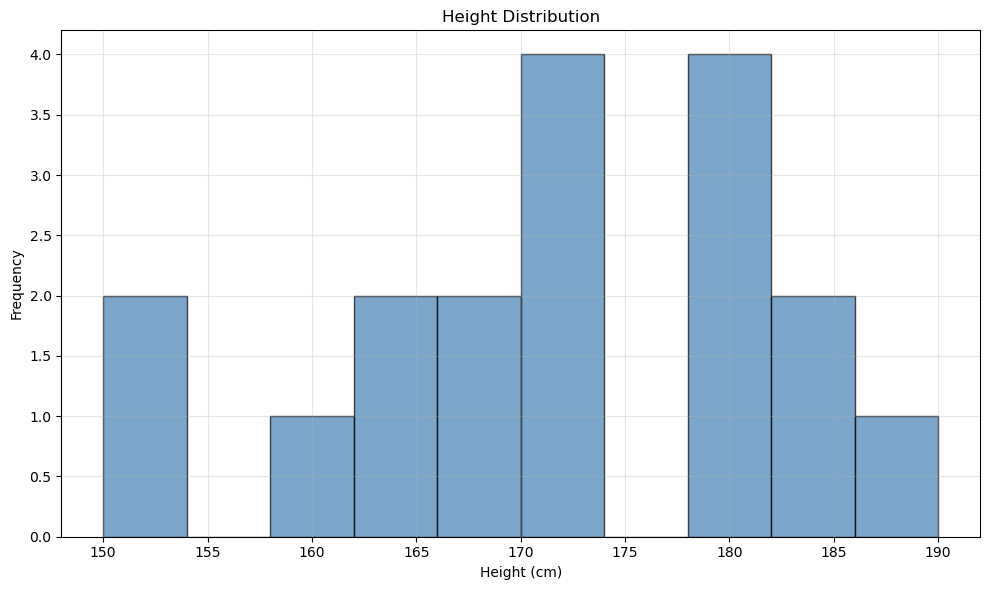


Task 3 completed successfully!


In [4]:
"""
Practice Task 3: Working with CSV Files and Visualising Data in Python
Student: Nitesh Singh
Student Height Logger - CSV handling, summary statistics, and visualization

This version includes pre-populated sample data for testing/demonstration.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =============================================================================
# TASK 1: CSV FILE SETUP
# =============================================================================

print("=" * 50)
print("=== Task 1: CSV File Setup ===")
print("=" * 50)

csv_filename = "heights.csv"

# Check if file exists
if os.path.exists(csv_filename):
    # File exists - open for appending
    print(f"\n'{csv_filename}' already exists.")
    print(f"'{csv_filename}' is open for appending.")
    file_mode = 'a'
    write_header = False
else:
    # File doesn't exist - create it with header
    print(f"\n'{csv_filename}' created successfully.")
    file_mode = 'w'
    write_header = True


# =============================================================================
# TASK 2: DATA ENTRY (Using sample data from assignment)
# =============================================================================

print("\n" + "=" * 50)
print("=== Task 2: Data Entry ===")
print("=" * 50 + "\n")

# Sample data from the assignment specification
sample_data = [
    {'Name': 'Amy', 'Height': 165},
    {'Name': 'Ben', 'Height': 172},
    {'Name': 'Ali', 'Height': 166},
    {'Name': 'Yin', 'Height': 180},
    {'Name': 'Mohammed', 'Height': 170},
    {'Name': 'Gus', 'Height': 182}
]

# Simulate user input output
for record in sample_data:
    print(f"Enter name (or 'q' to quit): {record['Name']}")
    print(f"Enter height (cm): {record['Height']}")
    print()

print("Enter name (or 'q' to quit): q")

# Write records to CSV file
records = sample_data
if records:
    with open(csv_filename, file_mode) as f:
        if write_header:
            f.write("Name,Height\n")
        for record in records:
            f.write(f"{record['Name']},{record['Height']}\n")
    print(f"\nData saved to {csv_filename}")
else:
    if write_header:
        with open(csv_filename, 'w') as f:
            f.write("Name,Height\n")
    print("\nNo new data entered.")


# =============================================================================
# TASK 3: SUMMARY STATISTICS
# =============================================================================

print("\n" + "=" * 50)
print("=== Task 3: Summary Statistics ===")
print("=" * 50 + "\n")

# Read the CSV file into a DataFrame
df = pd.read_csv(csv_filename)

# Calculate statistics using pandas and NumPy
total_records = len(df)
avg_height = np.mean(df['Height'])
min_height = np.min(df['Height'])
max_height = np.max(df['Height'])

# Print summary statistics
print(f"Total number of records: {total_records}")
print(f"Average height: {avg_height:.2f} cm")
print(f"Minimum height: {min_height} cm")
print(f"Maximum height: {max_height} cm")

# Save summary to text file
summary_filename = "height_summary.txt"
with open(summary_filename, 'w') as f:
    f.write("Height Summary Statistics\n")
    f.write("=" * 30 + "\n")
    f.write(f"Total number of records: {total_records}\n")
    f.write(f"Average height: {avg_height:.2f} cm\n")
    f.write(f"Minimum height: {min_height} cm\n")
    f.write(f"Maximum height: {max_height} cm\n")

print(f"\nSummary saved to {summary_filename}")


# =============================================================================
# TASK 4: VISUALISATION
# =============================================================================

print("\n" + "=" * 50)
print("=== Task 4: Visualisation ===")
print("=" * 50 + "\n")

# Create histogram using matplotlib
plt.figure(figsize=(10, 6))
plt.hist(df['Height'], bins=10, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Height Distribution')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('height_distribution.png', dpi=100)
print("Histogram saved to 'height_distribution.png'")

# Display the plot
plt.show()

print("\n" + "=" * 50)
print("Task 3 completed successfully!")
print("=" * 50)